QuickCommerce Insights
Analyzing Customer Sentiment and Platform Comparison

In the fast-paced world of quick commerce, platforms like BlinkIt, Zepto, and JioMart face growing customer dissatisfaction, as revealed through aggregated reviews and ratings. This dataset offers a unique chance to conduct Sentiment Analysis to classify feedback and perform Platform vs Platform Analysis to benchmark satisfaction. The objective is to identify key pain points and improve user experiences, with evaluation based on F1 Score for sentiment classification and ANOVA for platform analysis. This analysis aims to drive actionable insights for enhancing customer loyalty and maintaining a competitive edge.

Objective:
Identify key pain points and improve user experiences through sentiment analysis and platform comparison
Metrics:
F1-score, ANOVA
Dataset:
Download Dataset

In [12]:
import pandas as pd

data = pd.read_csv('Task1.csv')

# Basic inspection
print("Dataset Shape:", data.shape)
print("Columns:", data.columns)
print("Sample Data:\n", data.head())
print("Missing Values:\n", data.isnull().sum())

Dataset Shape: (4620, 4)
Columns: Index(['rating', 'date', 'review', 'platform'], dtype='object')
Sample Data:
    rating              date  \
0       2  30 December 2024   
1       1   4 November 2024   
2       1   31 October 2024   
3       5    29 August 2024   
4       2  31 December 2024   

                                              review platform  
0  I was using it for long time, but have to stop...  blinkit  
1  Loving the fast deliveries and mostly they are...  blinkit  
2  The customer support is very disappointing. I ...  blinkit  
3  I've been using Blinkit for a while now, and i...  blinkit  
4  Blinkit was my go to app and it was rare that ...  blinkit  
Missing Values:
 rating      0
date        0
review      0
platform    0
dtype: int64


In [13]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('all')


data = pd.read_csv('Task1.csv')

# 1. Data Cleaning
# Use actual column names: 'review' and 'rating'
data = data.dropna(subset=['review', 'rating'])
data = data.drop_duplicates()

# 2. Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

data['cleaned_review'] = data['review'].apply(preprocess_text)

# 3. Feature Engineering
def infer_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

data['sentiment'] = data['rating'].apply(infer_sentiment)

# Save preprocessed data
data.to_csv('preprocessed_data.csv', index=False)
print("Preprocessed Data Sample:\n", data[['cleaned_review', 'sentiment']].head())


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\KIIT0001\AppData\Roaming\nltk

Preprocessed Data Sample:
                                       cleaned_review sentiment
0  using long time stop using recently got used i...  negative
1  loving fast delivery mostly great quick delive...  negative
2  customer support disappointing recently bought...  negative
3  ive using blinkit become goto app grocery shop...  positive
4  blinkit go app rare disappointed mebut today d...  negative


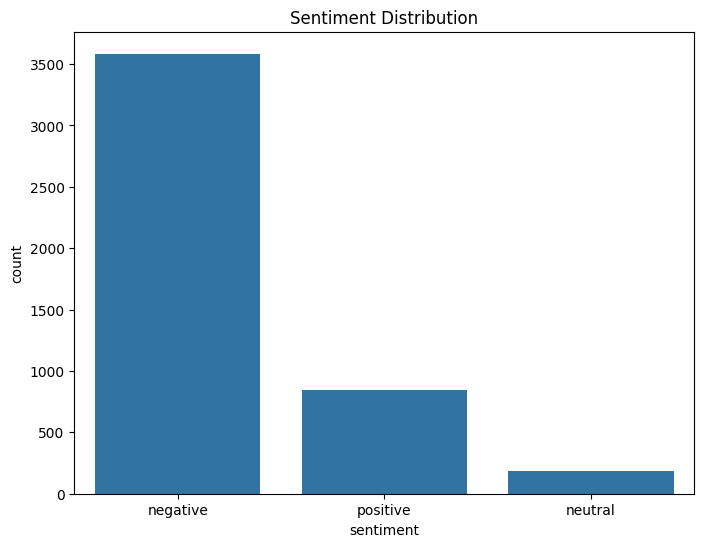

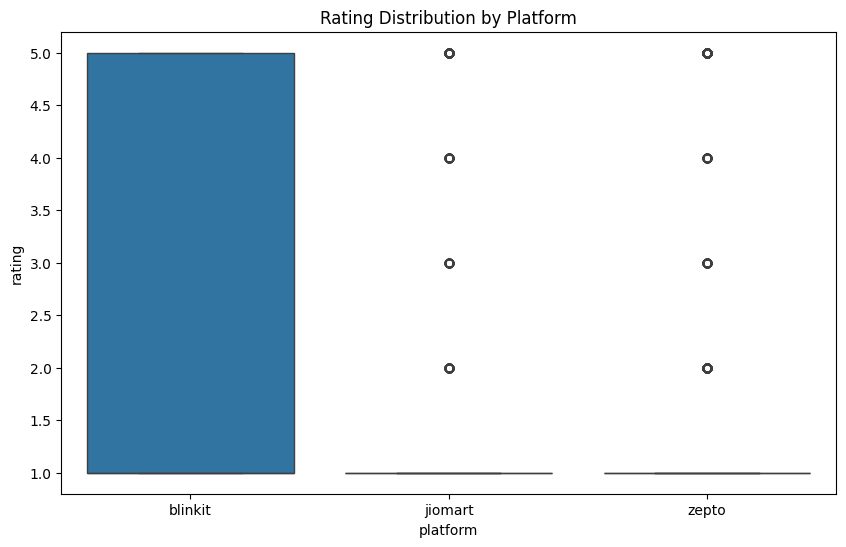

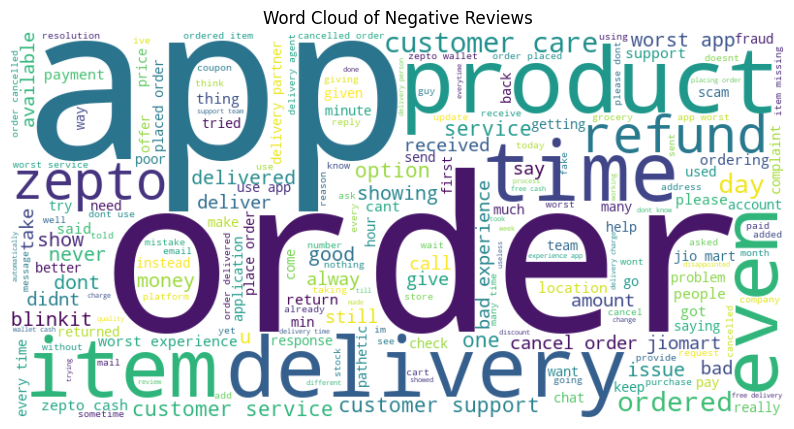

Platform Rating Stats:
            count      mean       std  min  25%  50%  75%  max
platform                                                     
blinkit   1380.0  2.552899  1.770588  1.0  1.0  1.0  5.0  5.0
jiomart   1500.0  1.502000  1.170289  1.0  1.0  1.0  1.0  5.0
zepto     1740.0  1.532184  1.186758  1.0  1.0  1.0  1.0  5.0


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load preprocessed data
data = pd.read_csv('preprocessed_data.csv')

# 1. Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=data)
plt.title('Sentiment Distribution')
plt.show()

# 2. Platform Comparison
plt.figure(figsize=(10, 6))
sns.boxplot(x='platform', y='rating', data=data)
plt.title('Rating Distribution by Platform')
plt.show()

# 3. Word Analysis (Negative Reviews)
negative_reviews = data[data['sentiment'] == 'negative']['cleaned_review'].str.cat(sep=' ')
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Negative Reviews')
plt.show()

# 4. Basic Stats
print("Platform Rating Stats:\n", data.groupby('platform')['rating'].describe())

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Load preprocessed data
data = pd.read_csv('preprocessed_data.csv')

# 1. Data Splitting
X = data['cleaned_review']
y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Extraction (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 4. Prediction and Evaluation
y_pred = model.predict(X_test_tfidf)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

# Save predictions
test_data = pd.DataFrame({'review': X_test, 'true_sentiment': y_test, 'predicted_sentiment': y_pred})
test_data.to_csv('sentiment_predictions.csv', index=False)

F1 Score: 0.8821512127578304


ANOVA F-Statistic: 271.21140780619874
P-Value: 4.316037879631715e-112


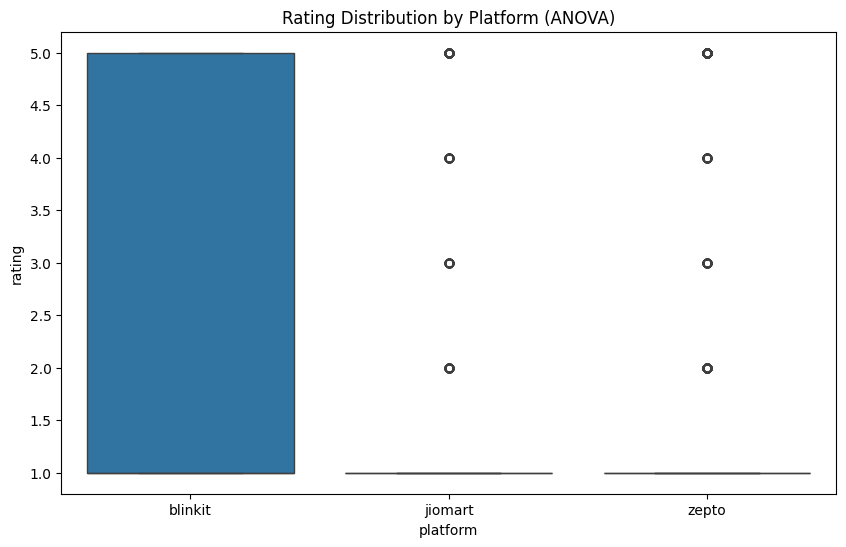

In [16]:
import pandas as pd
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv('preprocessed_data.csv')

# 1. Aggregate Data
platform_ratings = [data[data['platform'] == p]['rating'] for p in data['platform'].unique()]

# 2. ANOVA Test
f_stat, p_value = f_oneway(*platform_ratings)
print("ANOVA F-Statistic:", f_stat)
print("P-Value:", p_value)

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='platform', y='rating', data=data)
plt.title('Rating Distribution by Platform (ANOVA)')
plt.show()

In [17]:
import pandas as pd
from collections import Counter

# Load data with predictions
data = pd.read_csv('sentiment_predictions.csv')

# Filter negative reviews
negative_reviews = data[data['predicted_sentiment'] == 'negative']['review']

# Extract common words
all_words = ' '.join(negative_reviews).split()
word_freq = Counter(all_words).most_common(10)
print("Top 10 Pain Point Words:", word_freq)

# Save pain points
with open('pain_points.txt', 'w') as f:
    for word, freq in word_freq:
        f.write(f"{word}: {freq}\n")

Top 10 Pain Point Words: [('order', 632), ('app', 562), ('delivery', 420), ('customer', 351), ('product', 328), ('time', 302), ('item', 297), ('service', 251), ('zepto', 245), ('worst', 213)]


In [18]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv('preprocessed_data.csv')
X = data['cleaned_review']
y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Hyperparameter tuning
param_grid = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2']}
model = LogisticRegression(max_iter=1000, solver='liblinear')
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_tfidf, y_train)

# Best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_tfidf)
f1 = f1_score(y_test, y_pred, average='weighted')
print("Best F1 Score:", f1)
print("Best Parameters:", grid_search.best_params_)

Best F1 Score: 0.8915863188764152
Best Parameters: {'C': 10, 'penalty': 'l2'}


In [19]:
print(data.columns)

Index(['rating', 'date', 'review', 'platform', 'cleaned_review', 'sentiment'], dtype='object')


In [20]:
import pandas as pd

# Load data
data = pd.read_csv('sentiment_predictions.csv')

# Overall negative sentiment percentage
neg_count = (data['predicted_sentiment'] == 'negative').sum()
total = len(data)

print(f"Overall: {neg_count / total * 100:.2f}% negative reviews")


Overall: 84.96% negative reviews


In [21]:
import pandas as pd

# Load the predictions file
data = pd.read_csv('sentiment_predictions.csv')

# Print column names and a sample
print("Column Names:", data.columns.tolist())
print("Sample Data:\n", data.head())

Column Names: ['review', 'true_sentiment', 'predicted_sentiment']
Sample Data:
                                               review true_sentiment  \
0  unprofessional issue regarding order still wai...       negative   
1  recently ordered item app amounting r approx i...       negative   
2  service worst like accepted jio specially time...       negative   
3  blinkit need see illegible getting gift defaul...       negative   
4  horrible experience payment order showed cance...       negative   

  predicted_sentiment  
0            negative  
1            negative  
2            negative  
3            negative  
4            negative  


In [22]:
import pandas as pd

# Load data
data = pd.read_csv('sentiment_predictions.csv')

# Add a dummy 'platform' column
data['platform'] = 'app'  # or assign different values based on your criteria

# Ensure required columns exist
required_columns = ['platform', 'predicted_sentiment']
for col in required_columns:
    if col not in data.columns:
        raise ValueError(f"Column '{col}' not found in 'sentiment_predictions.csv'")

# Summary per platform
platforms = data['platform'].unique()
for platform in platforms:
    platform_data = data[data['platform'] == platform]
    neg_count = (platform_data['predicted_sentiment'] == 'negative').sum()
    total = len(platform_data)
    print(f"{platform}: {neg_count/total*100:.2f}% negative reviews")


app: 84.96% negative reviews
